In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [3]:
# -*- coding: utf-8 -*-
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from matplotlib.ticker import FixedLocator, FixedFormatter
import matplotlib as mpl

# Configuración estética y reproducibilidad
plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

In [4]:
N_CLUSTERS_REAL = np.random.randint(2, 21)   1-20 (usamos 2-20 para métricas válidas)

def generate_well_separated_centroids(n, min_dist=5.0, bounds=(-18, 18), max_attempts=5000):
    """Genera n centroides 2D con distancia euclídea mínima garantizada."""
    centroids = []
    attempts = 0
    while len(centroids) < n and attempts < max_attempts:
        candidate = np.random.uniform(bounds[0], bounds[1], size=2)
        if len(centroids) == 0:
            centroids.append(candidate)
        else:
            dists = np.linalg.norm(np.array(centroids) - candidate, axis=1)
            if np.min(dists) >= min_dist:
                centroids.append(candidate)
        attempts += 1
    if len(centroids) < n:
        print(f"[ADVERTENCIA] Solo se generaron {len(centroids)} centroides con distancia >= {min_dist}")
    return np.array(centroids)

# Generación
blob_centers = generate_well_separated_centroids(N_CLUSTERS_REAL, min_dist=5.0)
blob_std = np.random.uniform(0.6, 1.3, size=len(blob_centers))

X, y_true = make_blobs(
    n_samples=3000,
    centers=blob_centers,
    cluster_std=blob_std,
    random_state=42
)

print(f">>> Clusters reales generados: {N_CLUSTERS_REAL}")
print(f"Forma de X: {X.shape}")

>>> Clusters reales generados: 8
Forma de X: (3000, 2)


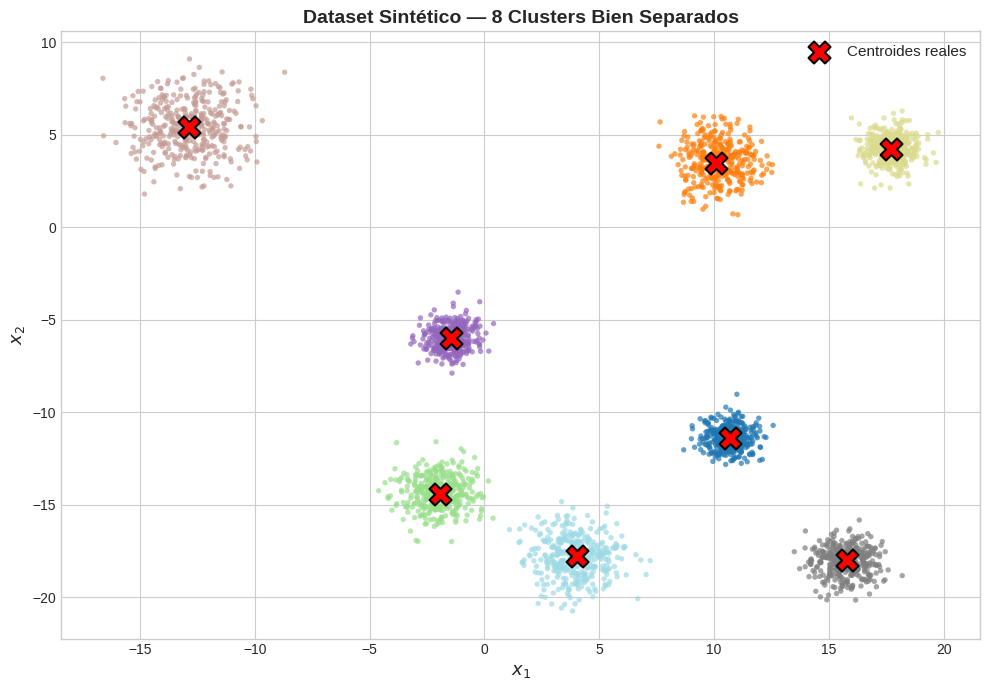

In [5]:
fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(
    X[:, 0], X[:, 1],
    c=y_true, cmap='tab20', s=15, alpha=0.7, edgecolors='none'
)
ax.scatter(
    blob_centers[:, 0], blob_centers[:, 1],
    c='red', marker='X', s=250, edgecolors='black', linewidths=1.5,
    label='Centroides reales', zorder=5
)
ax.set_title(f'Dataset Sintético — {N_CLUSTERS_REAL} Clusters Bien Separados', fontsize=14, fontweight='bold')
ax.set_xlabel('$x_1$', fontsize=13)
ax.set_ylabel('$x_2$', fontsize=13)
ax.legend(loc='upper right', fontsize=11)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

In [6]:
kmeans_opt = KMeans(
    n_clusters=N_CLUSTERS_REAL,
    init='k-means++',
    n_init=10,
    algorithm='lloyd',
    random_state=42
)
y_pred_opt = kmeans_opt.fit_predict(X)

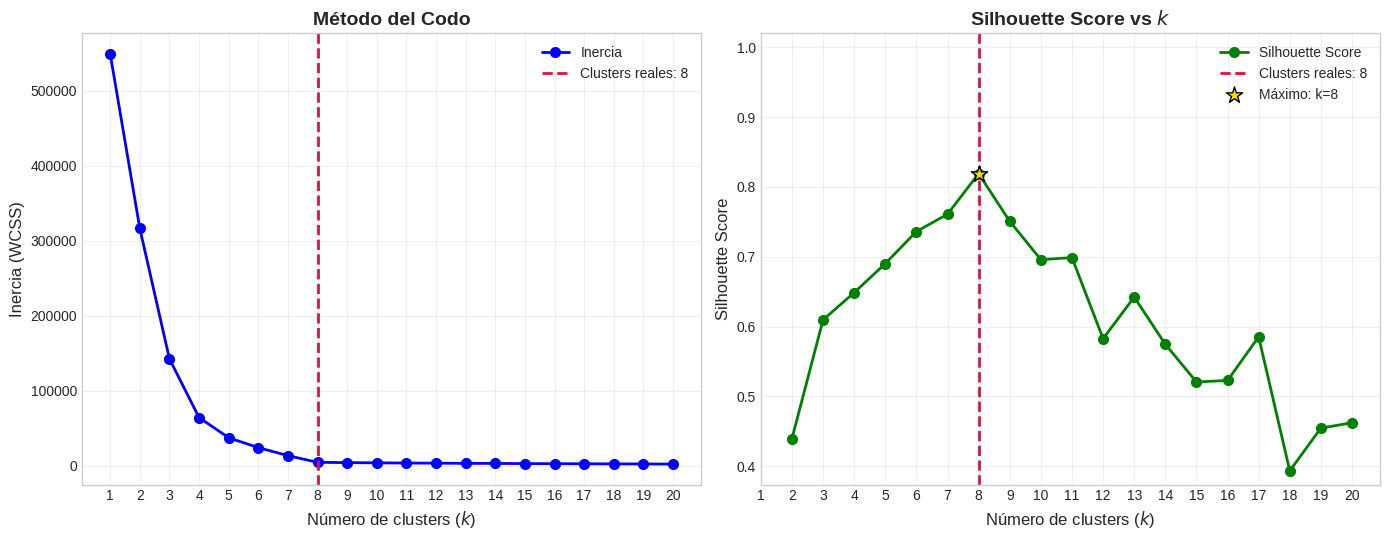

>>> Mejor k según Silhouette Score: 8 (score = 0.8192)


In [7]:
MAX_K = 20
k_range = range(1, MAX_K + 1)
inertias = []
silhouette_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X, km.labels_) if k > 1 else np.nan)

# Detección automática del mejor k por silhouette
best_k_sil = int(np.nanargmax(silhouette_scores) + 1)
best_score = np.nanmax(silhouette_scores)

# Visualización combinada
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# --- Método del Codo ---
axes[0].plot(k_range, inertias, 'bo-', markersize=7, linewidth=2, label='Inercia')
axes[0].axvline(x=N_CLUSTERS_REAL, color='crimson', linestyle='--', linewidth=2,
                label=f'Clusters reales: {N_CLUSTERS_REAL}')
axes[0].set_xlabel('Número de clusters ($k$)', fontsize=12)
axes[0].set_ylabel('Inercia (WCSS)', fontsize=12)
axes[0].set_title('Método del Codo', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(list(k_range))

# --- Silhouette Score ---
valid_k = list(range(2, MAX_K + 1))
valid_scores = silhouette_scores[1:]
axes[1].plot(valid_k, valid_scores, 'go-', markersize=7, linewidth=2, label='Silhouette Score')
axes[1].axvline(x=N_CLUSTERS_REAL, color='crimson', linestyle='--', linewidth=2,
                label=f'Clusters reales: {N_CLUSTERS_REAL}')
axes[1].scatter([best_k_sil], [best_score], c='gold', s=150, zorder=5, marker='*',
                edgecolors='black', linewidths=1, label=f'Máximo: k={best_k_sil}')
axes[1].set_xlabel('Número de clusters ($k$)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score vs $k$', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(list(k_range))
axes[1].set_ylim(bottom=min(valid_scores) * 0.95, top=1.02)

plt.tight_layout()
plt.show()

print(f">>> Mejor k según Silhouette Score: {best_k_sil} (score = {best_score:.4f})")

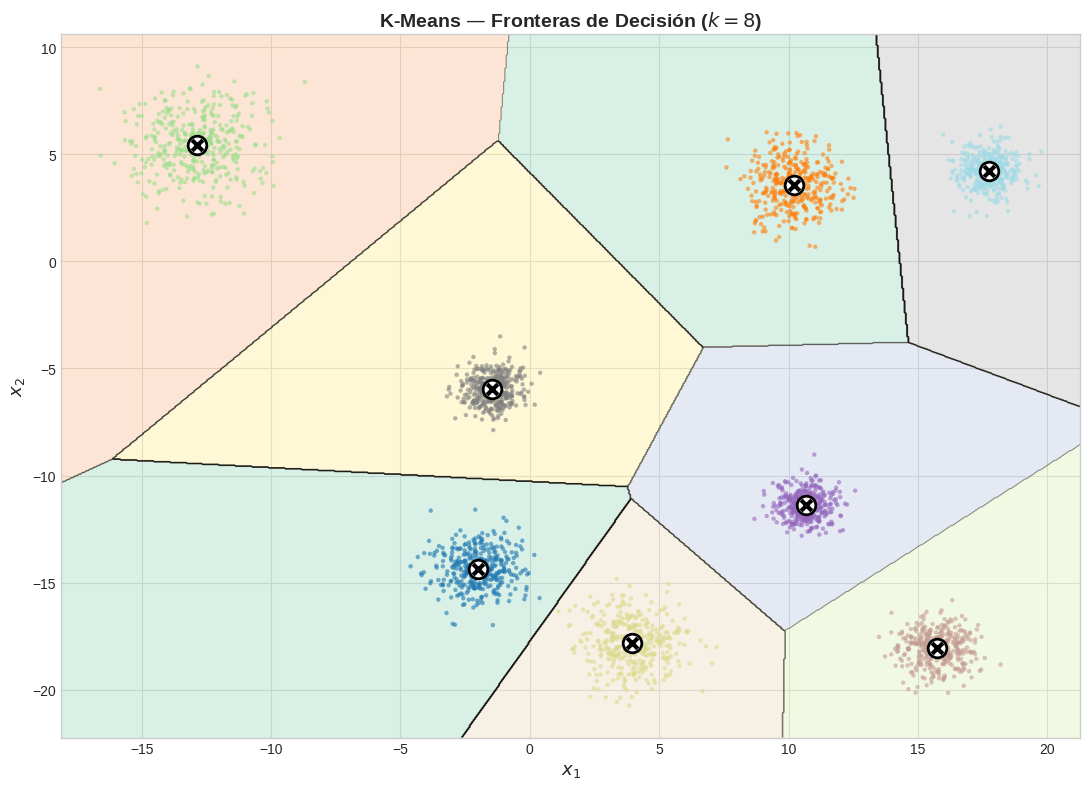

In [8]:
def plot_decision_boundaries(clusterer, X, y_pred, resolution=800):
    """Visualiza las fronteras de decisión de K-Means."""
    mins = X.min(axis=0) - 1.5
    maxs = X.max(axis=0) + 1.5
    xx, yy = np.meshgrid(
        np.linspace(mins[0], maxs[0], resolution),
        np.linspace(mins[1], maxs[1], resolution)
    )
    Z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(11, 8))
    plt.contourf(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                 cmap='Pastel2', alpha=0.5)
    plt.contour(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                linewidths=0.8, colors='k', alpha=0.4)

    # Puntos coloreados por cluster predicho
    plt.scatter(X[:, 0], X[:, 1], c=y_pred, cmap='tab20', s=10, alpha=0.6, edgecolors='none')

    # Centroides
    centers = clusterer.cluster_centers_
    plt.scatter(centers[:, 0], centers[:, 1],
                marker='o', s=180, c='white',
                edgecolors='black', linewidths=2, zorder=10)
    plt.scatter(centers[:, 0], centers[:, 1],
                marker='x', s=60, c='black', linewidths=3, zorder=11)

    plt.title(f'K-Means — Fronteras de Decisión ($k={clusterer.n_clusters}$)', fontsize=14, fontweight='bold')
    plt.xlabel('$x_1$', fontsize=13)
    plt.ylabel('$x_2$', fontsize=13)
    plt.tight_layout()
    plt.show()

plot_decision_boundaries(kmeans_opt, X, y_pred_opt)

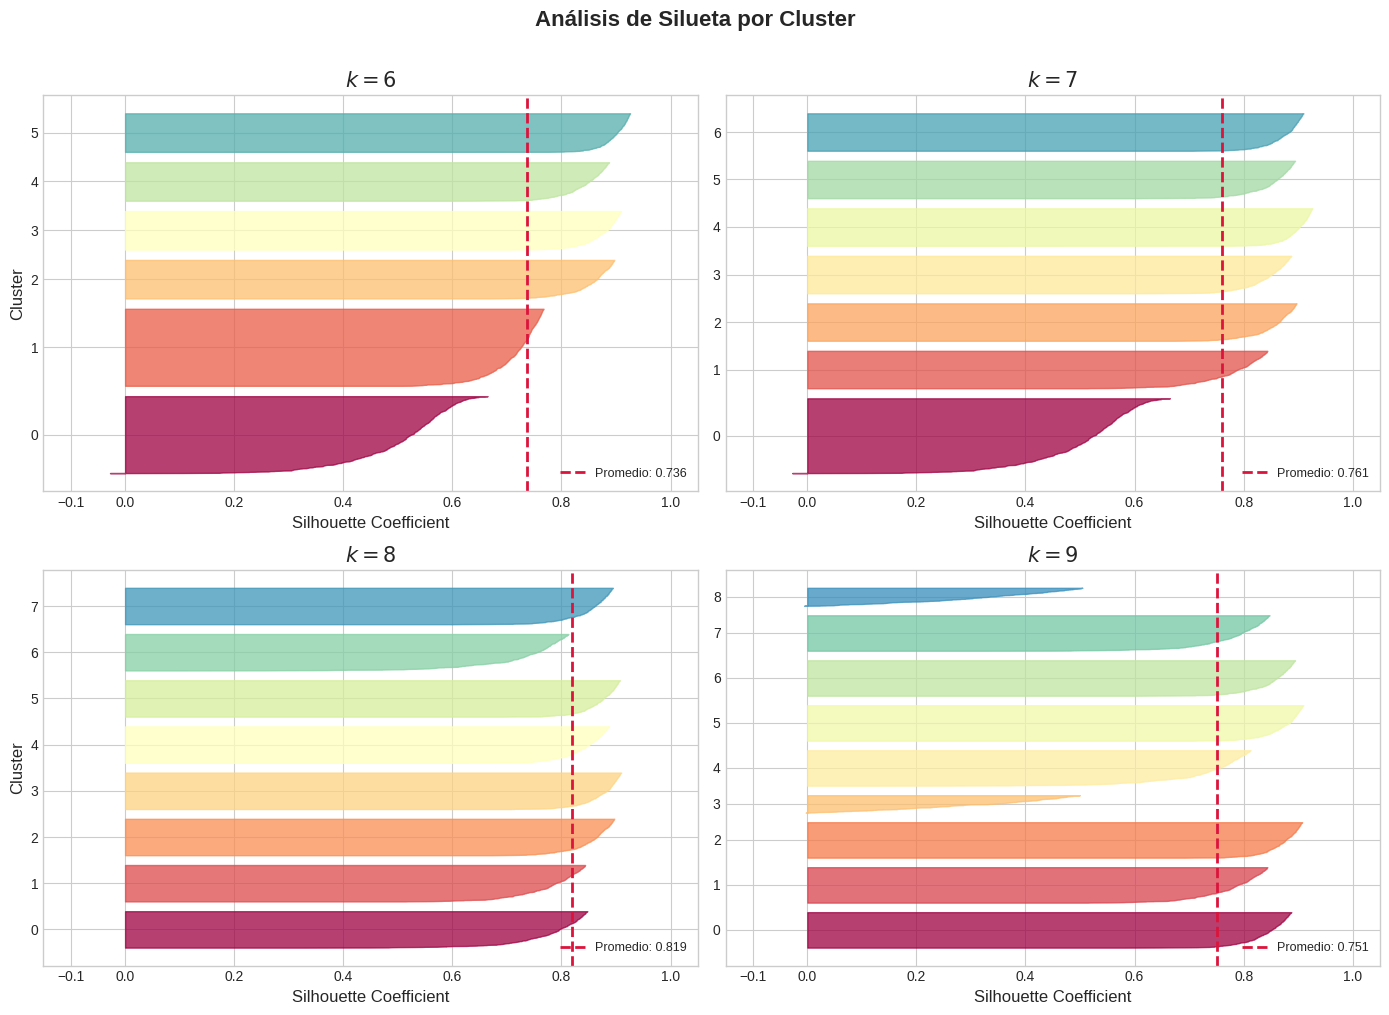

In [9]:
# Seleccionamos k cercanos al real para comparar visualmente
plot_ks_candidates = [N_CLUSTERS_REAL - 2, N_CLUSTERS_REAL - 1,
                      N_CLUSTERS_REAL, N_CLUSTERS_REAL + 1]
plot_ks = [k for k in plot_ks_candidates if k >= 2 and k <= MAX_K]
if len(plot_ks) < 4:
    extras = [k for k in range(2, MAX_K + 1) if k not in plot_ks]
    plot_ks = (plot_ks + extras)[:4]

# Pre-entrenar modelos para esos k
kmeans_per_k = {}
sil_scores_dict = {}
for k in plot_ks:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X)
    kmeans_per_k[k] = km
    sil_scores_dict[k] = silhouette_score(X, km.labels_)

plt.figure(figsize=(14, 10))
for plot_idx, k in enumerate(plot_ks):
    ax = plt.subplot(2, 2, plot_idx + 1)

    y_pred = kmeans_per_k[k].labels_
    silhouette_coefficients = silhouette_samples(X, y_pred)

    padding = len(X) // 30
    pos = padding
    ticks = []
    for i in range(k):
        coeffs = silhouette_coefficients[y_pred == i]
        coeffs.sort()
        color = mpl.cm.Spectral(i / k)
        plt.fill_betweenx(
            np.arange(pos, pos + len(coeffs)), 0, coeffs,
            facecolor=color, edgecolor=color, alpha=0.75
        )
        ticks.append(pos + len(coeffs) // 2)
        pos += len(coeffs) + padding

    ax.yaxis.set_major_locator(FixedLocator(ticks))
    ax.yaxis.set_major_formatter(FixedFormatter(range(k)))

    if plot_idx % 2 == 0:
        ax.set_ylabel("Cluster", fontsize=12)
    ax.set_xlabel("Silhouette Coefficient", fontsize=12)
    ax.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
    ax.set_xlim([-0.15, 1.05])

    avg_score = sil_scores_dict[k]
    ax.axvline(x=avg_score, color="crimson", linestyle="--", linewidth=2,
               label=f"Promedio: {avg_score:.3f}")
    ax.set_title(f"$k={k}$", fontsize=15, fontweight='bold')
    ax.legend(loc='lower right', fontsize=9)
    ax.set_axisbelow(True)

plt.suptitle("Análisis de Silueta por Cluster", fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

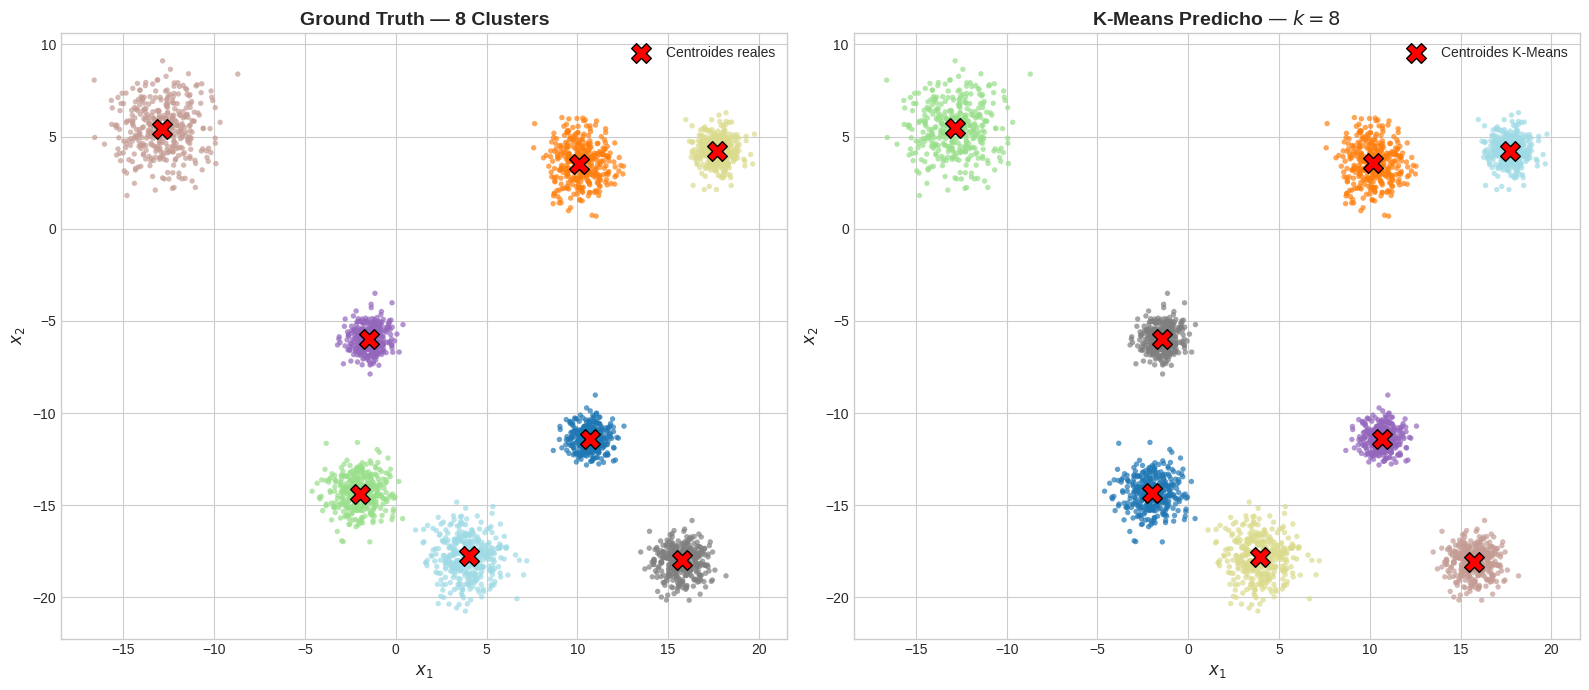


RESUMEN DE RESULTADOS
Clusters reales generados      : 8
Mejor k por Silhouette Score   : 8
Silhouette Score (k real)      : 0.8192
Inercia (k real)               : 4720.33
Número de muestras             : 3000


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Real
axes[0].scatter(X[:, 0], X[:, 1], c=y_true, cmap='tab20', s=15, alpha=0.7, edgecolors='none')
axes[0].scatter(blob_centers[:, 0], blob_centers[:, 1], c='red', marker='X', s=200,
                edgecolors='black', label='Centroides reales')
axes[0].set_title(f'Ground Truth — {N_CLUSTERS_REAL} Clusters', fontsize=14, fontweight='bold')
axes[0].set_xlabel('$x_1$', fontsize=12)
axes[0].set_ylabel('$x_2$', fontsize=12)
axes[0].legend()

# Predicho
axes[1].scatter(X[:, 0], X[:, 1], c=y_pred_opt, cmap='tab20', s=15, alpha=0.7, edgecolors='none')
axes[1].scatter(kmeans_opt.cluster_centers_[:, 0], kmeans_opt.cluster_centers_[:, 1],
                c='red', marker='X', s=200, edgecolors='black', label='Centroides K-Means')
axes[1].set_title(f'K-Means Predicho — $k={N_CLUSTERS_REAL}$', fontsize=14, fontweight='bold')
axes[1].set_xlabel('$x_1$', fontsize=12)
axes[1].set_ylabel('$x_2$', fontsize=12)
axes[1].legend()

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("RESUMEN DE RESULTADOS")
print("="*60)
print(f"Clusters reales generados      : {N_CLUSTERS_REAL}")
print(f"Mejor k por Silhouette Score   : {best_k_sil}")
print(f"Silhouette Score (k real)      : {silhouette_score(X, kmeans_opt.labels_):.4f}")
print(f"Inercia (k real)               : {kmeans_opt.inertia_:.2f}")
print(f"Número de muestras             : {len(X)}")
print("="*60)